<a href="https://colab.research.google.com/github/enzobanin/AnaliseDeDadosTemperatura/blob/luiz%2Fanalise-parte2/TempArInst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
from google.colab import drive
drive.mount('/content/drive')

#path = "/content/drive/MyDrive/Colab Notebooks/TemperaturaArInstantânea"
path = "/content/drive/MyDrive/5 semestre/TemperaturaArInstantânea"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
df = pd.read_csv(path + '/A519.csv', sep=';')
df.head(5)

,data,hora,pressao,radiacao,temp_inst,pto_orvalho_inst,umid_inst,vento_vel,Unnamed: 8
0,2013-12-03,0,949.3,-3.54,22.3,21.0,92.0,2.3,NaN
1,2013-12-03,100,949.7,-3.54,22.1,20.6,91.0,2.1,NaN
2,2013-12-03,200,949.4,-3.54,22.1,20.0,88.0,1.3,NaN
3,2013-12-03,300,949.1,-3.54,21.9,20.2,90.0,2.3,NaN
4,2013-12-03,400,948.6,-3.54,21.4,19.8,91.0,1.5,NaN


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83232 entries, 0 to 83231
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data              83232 non-null  object 
 1   hora              83232 non-null  int64  
 2   pressao           77953 non-null  float64
 3   radiacao          77953 non-null  float64
 4   temp_inst         77953 non-null  float64
 5   pto_orvalho_inst  77948 non-null  float64
 6   umid_inst         77947 non-null  float64
 7   vento_vel         77953 non-null  float64
 8   Unnamed: 8        0 non-null      float64
dtypes: float64(7), int64(1), object(1)
memory usage: 5.7+ MB


In [63]:
df[df['temp_inst'].isnull()]['data'].value_counts().sort_index()
#soma a quantidade de valores nulos por data - para verificarmos se os valores nulos
#estão agrupados ou separados

,count
data,
2014-02-23,9
2014-02-24,13
2014-02-25,21
2014-02-26,15
2014-02-27,14
...,...
2021-11-02,11
2021-11-03,12
2021-11-04,12


In [64]:
df.duplicated().sum()
#verifica duplicidade

np.int64(0)

In [65]:
df = df.dropna(subset=['temp_inst', 'pressao', 'radiacao', 'pto_orvalho_inst', 'umid_inst', 'vento_vel'])
df = df.drop(columns=['Unnamed: 8'])

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 77945 entries, 0 to 83231
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data              77945 non-null  object 
 1   hora              77945 non-null  int64  
 2   pressao           77945 non-null  float64
 3   radiacao          77945 non-null  float64
 4   temp_inst         77945 non-null  float64
 5   pto_orvalho_inst  77945 non-null  float64
 6   umid_inst         77945 non-null  float64
 7   vento_vel         77945 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 5.4+ MB


In [69]:
#mudar a data que veio do csv de string para dataTime
df['data'] = pd.to_datetime(df['data'], format='%Y-%m-%d')
#vai retornar o dia do ano para calculo posterior
dia_do_ano = df['data'].dt.dayofyear
#como 'hora' veio no formato HHMM, precisamos alterar
hora_do_dia = df['hora'] // 100

#a ideia vai ser espalhar as 24 horas do dia em um circulo para o algoritmo
#que vai estudar, sabera como funciona as horas,
#sera como um relogio analogico

#vamos fazer coordenadas com seno e cosseno para simular os horarios
df['hora_sin'] = np.sin(2 * np.pi * hora_do_dia / 24)
df['hora_cos'] = np.cos(2 * np.pi * hora_do_dia / 24)
#mesma logica porem vai representar o ano e nao as horas
df['dia_ano_sin'] = np.sin(2 * np.pi * dia_do_ano / 365.25)
df['dia_ano_cos'] = np.cos(2 * np.pi * dia_do_ano / 365.25)

df = df.drop(columns=['data', 'hora'])

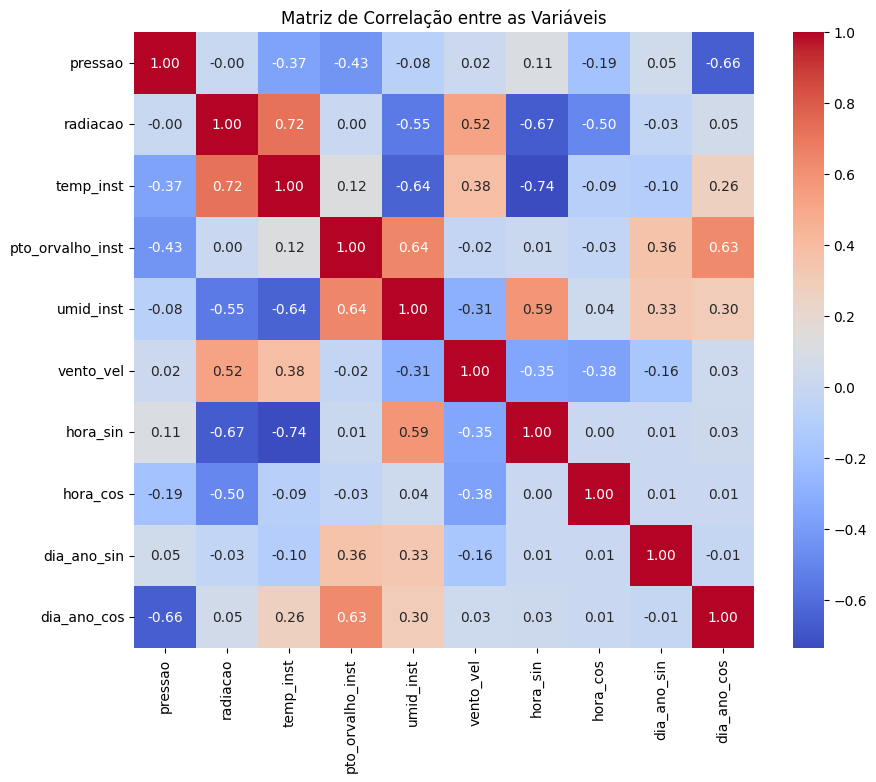

In [70]:
# Matriz de correlação entre as variáveis numéricas
correlacao = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação entre as Variáveis')
plt.show()

#Geramos a matriz de correlação para validar, de forma quantitativa, se o comportamento
#dos dados coletados é consistente

**Principais observações:**

- **`radiacao` e `temp_inst` (0.72)**: forte correlação positiva, confirmando o papel da
  radiação solar como motor energético do aquecimento do ar.
- **`umid_inst` e `temp_inst` (-0.64)**: correlação negativa relevante, consistente com a
  relação inversamente proporcional entre umidade relativa e temperatura descrita na
  física da atmosfera (ar mais quente retém mais vapor antes de saturar).
- **`hora_sin` e `temp_inst` (-0.74)**: a maior correlação encontrada com a variável
  alvo, mais forte até que a radiação. Isso reforça a importância da codificação cíclica
  do horário: o momento do dia, por si só, já é um forte preditor da temperatura.
- **`pto_orvalho_inst` e `temp_inst` (0.12)**: correlação positiva, porém mais fraca do
  que o esperado pela física teórica (ponto de orvalho deveria acompanhar mais de perto
  a temperatura). Isso sugere uma relação possivelmente não-linear entre essas variáveis,
  o que motiva a comparação entre modelos lineares e não-lineares (Decision Tree, Random
  Forest, SVR)
- **`umid_inst` e `pto_orvalho_inst` (0.64)**: correlação alta entre duas variáveis
  explicativas, indicando multicolinearidade. Isso justifica a exploração de
  regularização (ElasticNet) na Regressão Linear

In [52]:
# Split cronológico: 80% mais antigo para treino, 20% mais recente para teste
tamanho_treino = int(len(df) * 0.8)

df_treino = df.iloc[:tamanho_treino]
df_teste = df.iloc[tamanho_treino:]

X_treino = df_treino.drop(columns=['temp_inst'])
y_treino = df_treino['temp_inst']

X_teste = df_teste.drop(columns=['temp_inst'])
y_teste = df_teste['temp_inst']

print(f"Treino: {len(X_treino)} linhas")
print(f"Teste: {len(X_teste)} linhas")

#Utilizamos os primeiros 80% dos
#registros (cronologicamente) como conjunto de treino, e os 20% finais como conjunto de
#teste. Essa abordagem evita o vazamento de informação entre observações temporalmente
#próximas

Treino: 62356 linhas
Teste: 15589 linhas


In [71]:
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

def avaliar(nome, modelo, X_test, y_test):
    pred = modelo.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    return {'Modelo': nome, 'RMSE': round(rmse,4), 'MAE': round(mae,4), 'R²': round(r2,4)}

resultados = []

In [72]:
# EN_1: regularização fraca, equilibrada entre L1 e L2
en1 = ElasticNet(alpha=0.01, l1_ratio=0.5)
en1.fit(X_treino, y_treino)
resultados.append(avaliar('EN_1 (alpha=0.01, l1=0.5)', en1, X_teste, y_teste))

# EN_2: regularização moderada, mais Ridge — indicado pela multicolinearidade
# entre umid_inst e pto_orvalho_inst detectada na matriz de correlação
en2 = ElasticNet(alpha=0.1, l1_ratio=0.2)
en2.fit(X_treino, y_treino)
resultados.append(avaliar('EN_2 (alpha=0.1, l1=0.2)', en2, X_teste, y_teste))

# EN_3: regularização forte, mais Lasso — força eliminação de variáveis menos relevantes
en3 = ElasticNet(alpha=1.0, l1_ratio=0.8)
en3.fit(X_treino, y_treino)
resultados.append(avaliar('EN_3 (alpha=1.0, l1=0.8)', en3, X_teste, y_teste))

print("✓ ElasticNet concluído")

✓ ElasticNet concluído


In [73]:
# DT_1: árvore rasa — modelo simples, baixo risco de overfitting
dt1 = DecisionTreeRegressor(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42)
dt1.fit(X_treino, y_treino)
resultados.append(avaliar('DT_1 (depth=5)', dt1, X_teste, y_teste))

# DT_2: profundidade média — equilíbrio entre bias e variância
dt2 = DecisionTreeRegressor(max_depth=10, min_samples_split=5, min_samples_leaf=2, random_state=42)
dt2.fit(X_treino, y_treino)
resultados.append(avaliar('DT_2 (depth=10)', dt2, X_teste, y_teste))

# DT_3: árvore profunda — captura padrões detalhados, maior risco de overfitting
dt3 = DecisionTreeRegressor(max_depth=20, min_samples_split=2, min_samples_leaf=1, random_state=42)
dt3.fit(X_treino, y_treino)
resultados.append(avaliar('DT_3 (depth=20)', dt3, X_teste, y_teste))

print("✓ Decision Tree concluído")

✓ Decision Tree concluído


In [74]:
# RF_1: baseline do ensemble — 50 árvores, rápido
rf1 = RandomForestRegressor(n_estimators=50, max_features='sqrt', bootstrap=True, random_state=42)
rf1.fit(X_treino, y_treino)
resultados.append(avaliar('RF_1 (50 árvores)', rf1, X_teste, y_teste))

# RF_2: mais árvores e menos features por divisão — maior diversidade entre árvores
rf2 = RandomForestRegressor(n_estimators=100, max_features='log2', bootstrap=True, random_state=42)
rf2.fit(X_treino, y_treino)
resultados.append(avaliar('RF_2 (100 árvores, log2)', rf2, X_teste, y_teste))

# RF_3: sem substituição na amostragem — cada árvore vê dados únicos sem repetição
rf3 = RandomForestRegressor(n_estimators=200, max_features='sqrt', bootstrap=False, random_state=42)
rf3.fit(X_treino, y_treino)
resultados.append(avaliar('RF_3 (200 árvores, sem bootstrap)', rf3, X_teste, y_teste))

print("✓ Random Forest concluído")

✓ Random Forest concluído


In [75]:
# SVR exige normalização dos dados — escala afeta diretamente o kernel
scaler = StandardScaler()
X_treino_sc = scaler.fit_transform(X_treino)
X_teste_sc  = scaler.transform(X_teste)

# SVR_1: kernel linear — modelo mais simples, serve de baseline
svr1 = SVR(kernel='linear', C=1.0, epsilon=0.1)
svr1.fit(X_treino_sc, y_treino)
resultados.append(avaliar('SVR_1 (linear)', svr1, X_teste_sc, y_teste))

# SVR_2: kernel RBF — captura relações não-lineares do clima
svr2 = SVR(kernel='rbf', C=10.0, epsilon=0.1)
svr2.fit(X_treino_sc, y_treino)
resultados.append(avaliar('SVR_2 (rbf, C=10)', svr2, X_teste_sc, y_teste))

# SVR_3: RBF com C alto e epsilon maior — mais flexível, maior tolerância a erros
svr3 = SVR(kernel='rbf', C=100.0, epsilon=0.5)
svr3.fit(X_treino_sc, y_treino)
resultados.append(avaliar('SVR_3 (rbf, C=100)', svr3, X_teste_sc, y_teste))

print("✓ SVR concluído")

✓ SVR concluído
